# QDM Evaluation - May Forecast
### Comparison of Climate Data and Projections between QDM and Delta Shift Bias Adjustments using May 2026 ECMWF Seasonal Forecasts

### Emily Zuetell
### August 5, 2026

In [11]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [ ]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [ ]:
# Projection Effects
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
effect_qdm = xr.open_datatree(
    "gs://poreallas-public-20260605/v20260731/parsed/effects.zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [ ]:
impact_delta = analysis_utils.compute_impact(
    effect,
    socioeconomics,
    chunks={"number": -1, "region": "auto"},
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="coldonly",
    rate=False,
    age_weight=True,
)
impact_qdm = analysis_utils.compute_impact(
    effect_qdm,
    socioeconomics,
    chunks={"number": -1, "region": "auto"},
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="coldonly",
    rate=False,
    age_weight=True,
)

# TAS Comparison

In [5]:
# QDM
era5_qdm = (
    xr.open_dataset(
        "gs://poreallas-public-20260605/v20260731/parsed/era5_adj.zarr",
        chunks={"time": -1},
        backend_kwargs={"storage_options": {"token": "anon"}},
    )
    .groupby("time.month")
    .mean()
    .sel(month=[5, 6, 7, 8, 9, 10])
)
forecast_qdm = (
    xr.open_dataset(
        "gs://poreallas-public-20260605/v20260731/parsed/forecast_adj.zarr",
        chunks={"time": -1},
        backend_kwargs={"storage_options": {"token": "anon"}},
    )
    .mean(dim="number")
    .groupby("time.month")
    .mean()
    .sel(month=[5, 6, 7, 8, 9, 10])
)

forecast_qdm = isku_utils.grid_to_ir(forecast_qdm, savefile=None)
era5_qdm = isku_utils.grid_to_ir(era5_qdm, savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [6]:
## Delta Shift
forecast_gmfd = (
    xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))
    .mean(dim="number")
    .groupby("time.month")
    .mean()
)
era5_gmfd = (
    xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))
    .groupby("time.month")
    .mean()
    .sel(month=[5, 6, 7, 8, 9, 10])
)

In [7]:
# Raw
forecast_raw = (
    xr.open_zarr(os.path.join(DATA_DIR, "tas_forecast.zarr"))
    .mean(dim="number")
    .swap_dims({"forecast_period": "valid_time"})
    .groupby("valid_time.month")
    .mean()
)
era5_raw = (
    xr.open_zarr(os.path.join(DATA_DIR, "tas_ERA5.zarr"))
    .groupby("time.month")
    .mean()
    .sel(month=[5, 6, 7, 8, 9, 10])
)

forecast_raw = isku_utils.grid_to_ir(forecast_raw, savefile=None)
era5_raw = isku_utils.grid_to_ir(era5_raw, savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

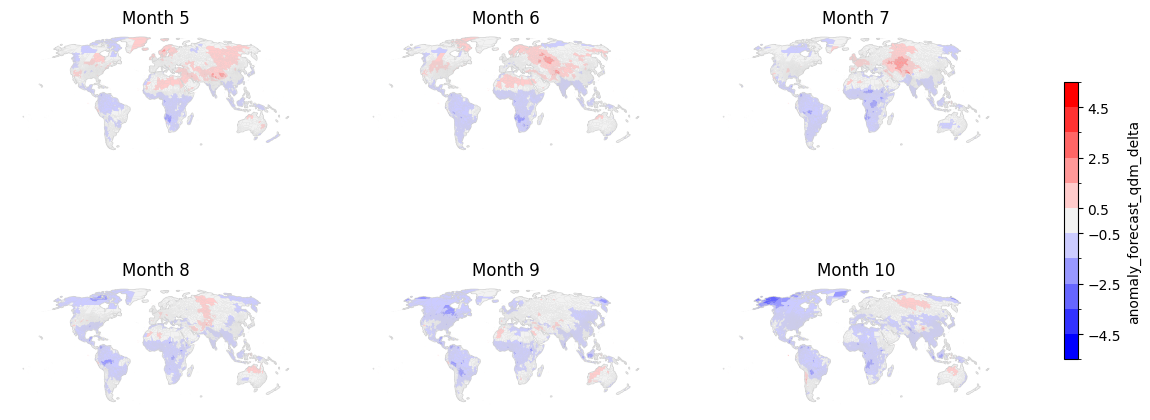

In [28]:
diff = forecast_qdm - forecast_gmfd

_polygons_delta = analysis_utils.xarray_to_gpd(diff["tas"], _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="tas",
    cm="bwr",
    vmin=-5,
    vmax=5,
    sup_title="",
    cbar_label="anomaly_forecast_qdm_delta",
)

fig.savefig("anomaly_forecast_qdm_delta.png", dpi=600, bbox_inches="tight")

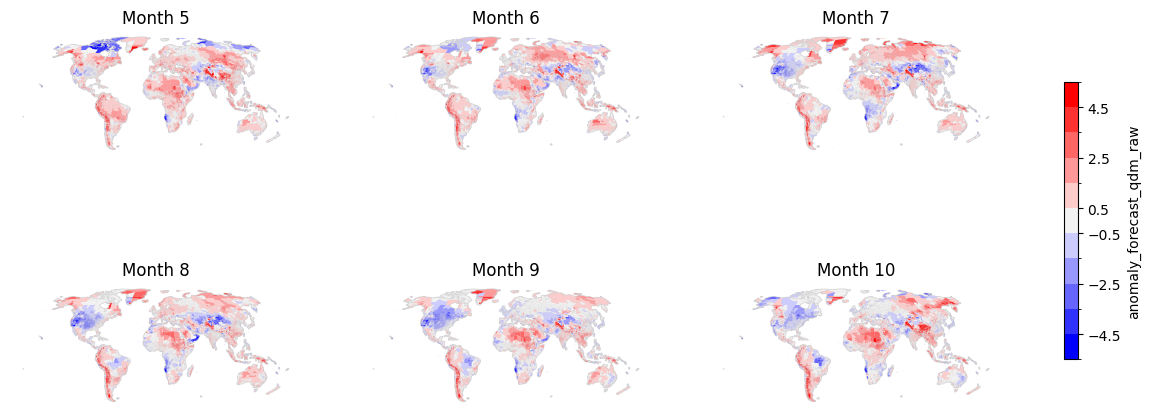

In [29]:
diff = forecast_qdm - forecast_raw

_polygons_delta = analysis_utils.xarray_to_gpd(diff["tas"], _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="tas",
    cm="bwr",
    vmin=-5,
    vmax=5,
    sup_title="",
    cbar_label="anomaly_forecast_qdm_raw",
)

fig.savefig("anomaly_forecast_qdm_raw.png", dpi=600, bbox_inches="tight")

### ERA5

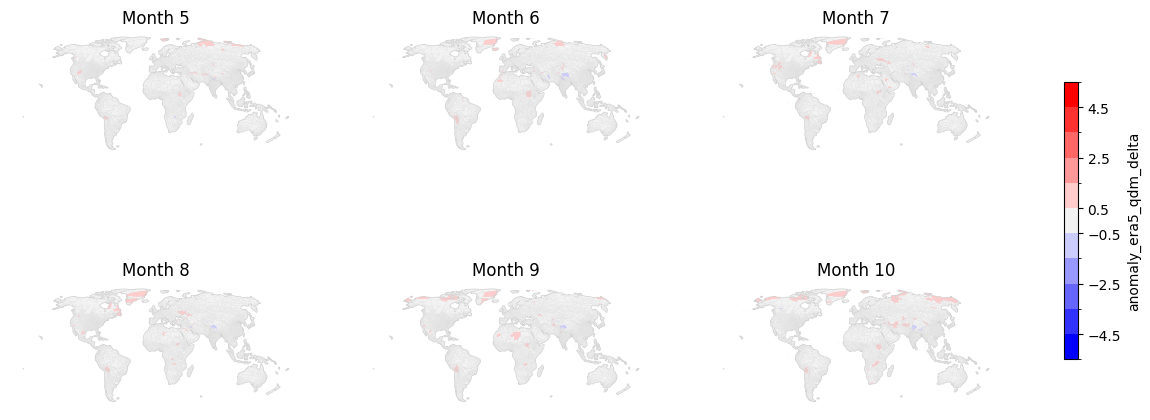

In [9]:
diff = era5_qdm - era5_gmfd

_polygons_delta = analysis_utils.xarray_to_gpd(diff["tas"], _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="tas",
    cm="bwr",
    vmin=-5,
    vmax=5,
    sup_title="",
    cbar_label="anomaly_era5_qdm_delta",
)

fig.savefig("anomaly_era5_qdm_delta.png", dpi=600, bbox_inches="tight")

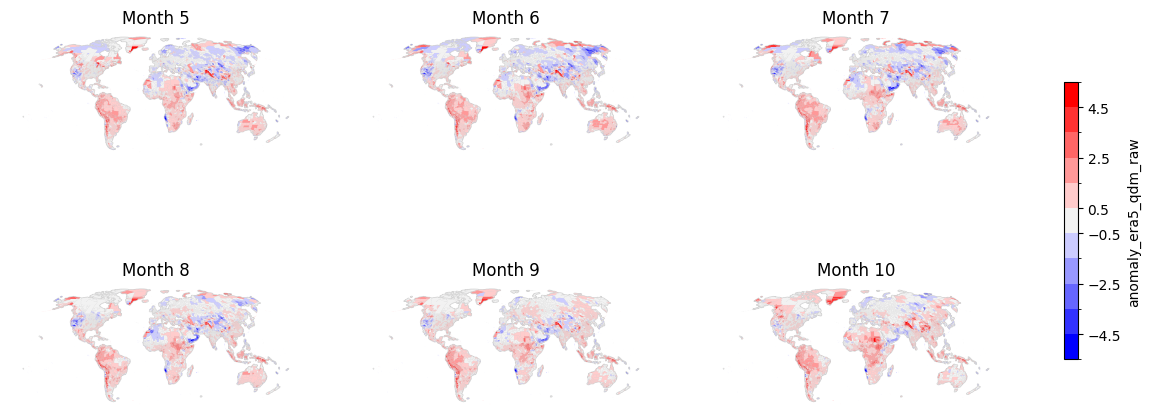

In [8]:
diff = era5_qdm - era5_raw

_polygons_delta = analysis_utils.xarray_to_gpd(diff["tas"], _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="tas",
    cm="bwr",
    vmin=-5,
    vmax=5,
    sup_title="",
    cbar_label="anomaly_era5_qdm_raw",
)

fig.savefig("anomaly_era5_qdm_raw.png", dpi=600, bbox_inches="tight")

### Forecast-ERA5

In [ ]:
diff = forecast_qdm - era5_qdm

_polygons_delta = analysis_utils.xarray_to_gpd(diff["tas"], _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="tas",
    cm="bwr",
    vmin=-5,
    vmax=5,
    sup_title="",
    cbar_label="anomaly_forecast_era5_qdm",
)

fig.savefig("anomaly_forecast_era5_qdm.png", dpi=600, bbox_inches="tight")

# Effect Comparison

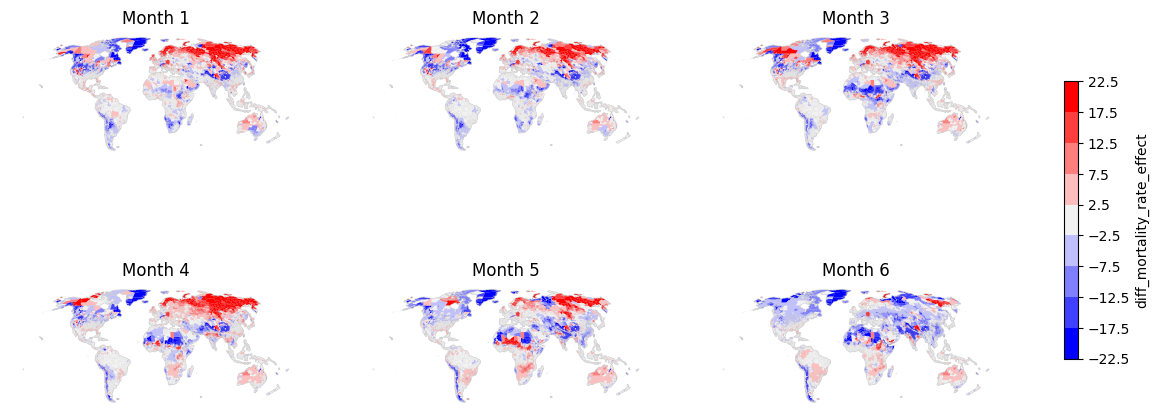

In [37]:
effect_delta_temp = (
    effect["/baseline"]["effect"]
    .sel(age_cohort="age65plus")
    .groupby("time.month")
    .mean()
)
effect_qdm_temp = (
    effect_qdm["/baseline"]["effect"]
    .sel(age_cohort="age65plus")
    .groupby("time.month")
    .mean()
)

diff = effect_qdm_temp - effect_delta_temp

_polygons_delta = analysis_utils.xarray_to_gpd(diff, _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="effect",
    cm="bwr",
    vmax=20,
    vmin=-20,
    sup_title="",
    cbar_label="diff_mortality_rate_effect",
)

fig.savefig(
    "diff_mortality_rate_65plus_effect_baseline.png", dpi=600, bbox_inches="tight"
)

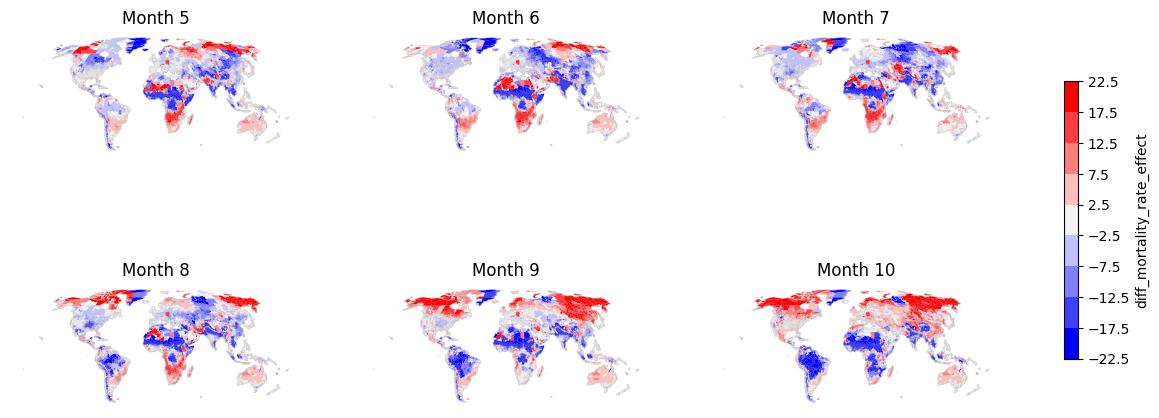

In [36]:
effect_delta_temp = (
    effect["/forecast"]["effect"]
    .sel(age_cohort="age65plus")
    .groupby("time.month")
    .mean()
    .mean(dim="number")
)
effect_qdm_temp = (
    effect_qdm["/forecast"]["effect"]
    .sel(age_cohort="age65plus")
    .groupby("time.month")
    .mean()
    .mean(dim="number")
)

diff = effect_qdm_temp - effect_delta_temp

_polygons_delta = analysis_utils.xarray_to_gpd(diff, _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="effect",
    cm="bwr",
    vmax=20,
    vmin=-20,
    sup_title="",
    cbar_label="diff_mortality_rate_effect",
)

fig.savefig(
    "diff_mortality_rate_65plus_effect_forecast.png", dpi=600, bbox_inches="tight"
)

# Impact Comparison

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


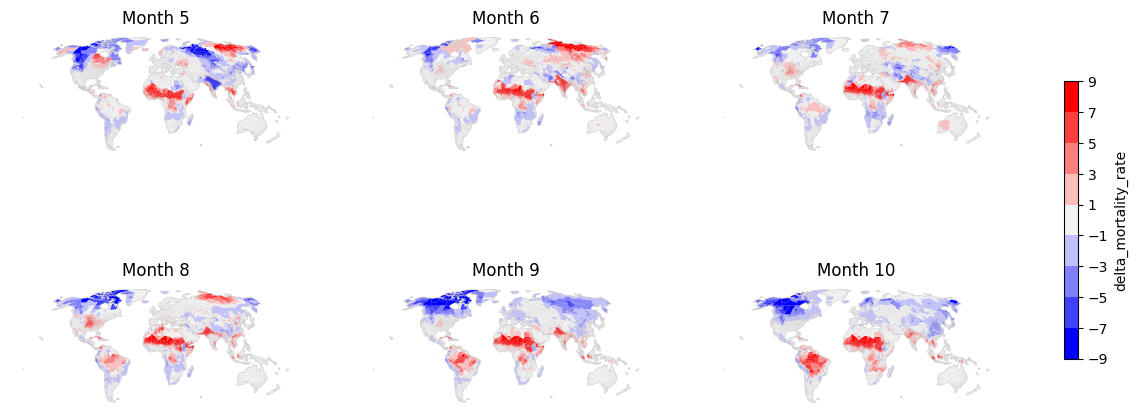

In [19]:
_polygons_delta = analysis_utils.xarray_to_gpd(
    impact_delta.mean(dim="number"), _polygons
)
fig = analysis_utils.plot_monthly(
    _polygons_delta,
    col="age_weighted_impact",
    cm="bwr",
    vmax=7,
    vmin=-7,
    sup_title="",
    cbar_label="delta_mortality_rate",
)

fig.savefig("delta_mortality_rate.png", dpi=600, bbox_inches="tight")

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


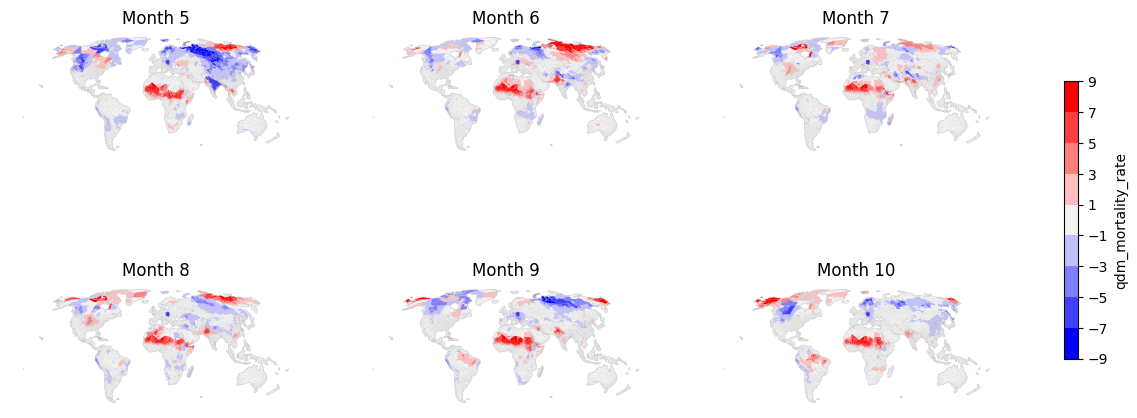

In [18]:
_polygons_qdm = analysis_utils.xarray_to_gpd(impact_qdm.mean(dim="number"), _polygons)
fig = analysis_utils.plot_monthly(
    _polygons_qdm,
    col="age_weighted_impact",
    cm="bwr",
    vmax=7,
    vmin=-7,
    sup_title="",
    cbar_label="qdm_mortality_rate",
)

fig.savefig("qdm_mortality_rate.png", dpi=600, bbox_inches="tight")

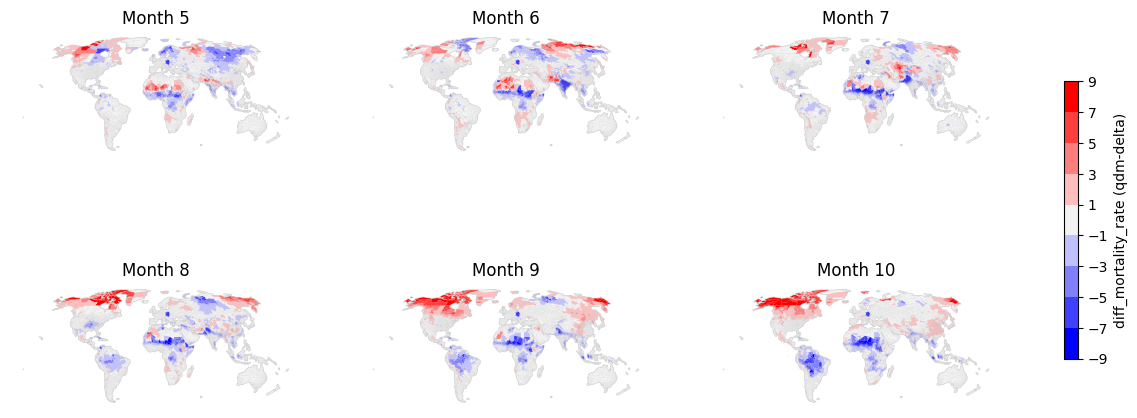

In [ ]:
diff = impact_qdm - impact_delta
_polygons_impact = analysis_utils.xarray_to_gpd(diff.mean(dim="number"), _polygons)

fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col="age_weighted_impact",
    cm="bwr",
    vmax=7,
    vmin=-7,
    sup_title="",
    cbar_label="diff_mortality_rate (qdm-delta)",
)

fig.savefig("diff_mortality_rate_qdmSUBdelta.png", dpi=600, bbox_inches="tight")